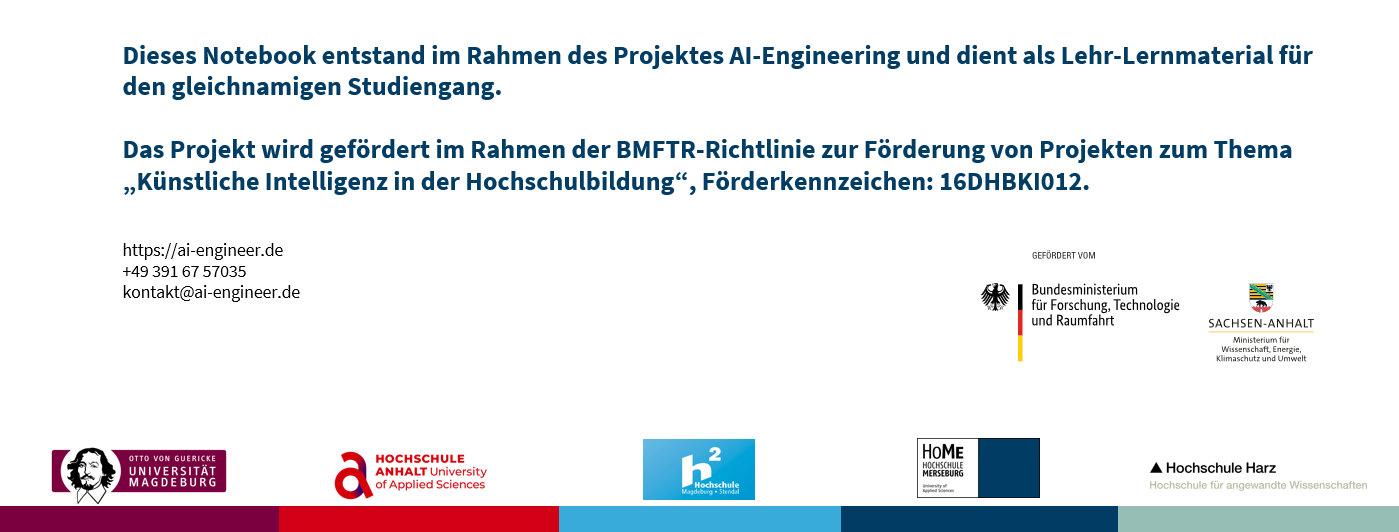

### Hinweise zu Erstellung und Lizenz der Notebookreihe
Diese Datei ist Teil der Reihe KI in der Prozessautomation, eine Lehrveranstaltung an der Hochschule Merseburg, Merseburg, Deutschland.

Sie sollte zusammen mit den Vorlesungsfolien und weiteren Materialien genutzt werden. Eine Kopie der Materialien ist zusammen mit dem Lizenztext zu nutzen und weiterzugeben, ebenso sollen Übungs- und Praktikumsblättern sowie eine geeignete Testumgebung für die Praktika zur Verfügung stehen.

Ursprünglich erstellt durch APMonitor 2020 unter MIT Lizenz (siehe beigefügte License im Repo-Ordner). Diese Version wurde auf deutsch übersetzt und mit geringen Anpassungen veröffentlicht.


## 2. Daten importieren und exportieren

[Data Science Playlist auf YouTube](https://www.youtube.com/watch?v=H05A_rftppU&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy)
[![Python Data Science](https://apmonitor.com/che263/uploads/Begin_Python/DataScience02.png)](https://www.youtube.com/watch?v=H05A_rftppU&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy "Python Data Science")

Python bietet Funktionen zum Lesen, Erstellen und Löschen von Dateien. Ein typischer Workflow in datengetriebenen Anwendungen ist: Daten importieren, Daten analysieren, Ergebnisse exportieren.

### `open` zum Lesen oder Schreiben einer Datei

Eine grundlegende Funktion zur Arbeit mit Dateien ist `open(filename,mode)`. Dabei ist `filename` ein String, der die zu öffnende Datei angibt, und `mode` bestimmt, wie die Datei geöffnet werden soll: `'r'` für read - Lesen, `'a'` für attach - Anhängen, `'w'` für write - Schreiben und `'x'` für exclusive creation - Erstellen (gibt einen Fehler zurück, wenn die Datei bereits existiert). Zusätzlich kann angegeben werden, ob die Datei als Text (`'t'`) oder binär (`'b'`) behandelt werden soll. Standardmäßig gilt `'rt'`, also das Lesen einer Datei im Textmodus.

In [11]:
# Testdatei mit einer Nachricht erstellen
f = open('02-file.txt','w')
f.write('This is a test file')
f.close()

import os
print('File stored in: ' + os.getcwd())

# Datei lesen und Inhalt ausgeben
f = open('02-file.txt')
print(f.read())
f.close()

File stored in: D:\Data_Code\Code\1 Code - Process control\1Code AIPC - Chaos\2025_TClab_data science
This is a test file


![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Daten in Dateien schreiben

Ein gängiges Datei-Format ist Comma Separated Values (CSV), bei dem Einträge durch Kommata getrennt werden. Angenommen, es gibt einige Daten `m`, die wir zusammen mit Kopfzeilen aus Listen in Python `clist` in eine CSV-Datei schreiben möchten. Das folgende Beispiel zeigt, wie sich eine CSV-Datei mit verschiedenen Modulen erstellen lässt.

```
x,y,z
1,2,3
4,5,6
7,8,9
```

Nach dem Ausführen jeder Zelle können Sie die im aktuellen Arbeitsverzeichnis erstellte Datei entweder mit Excel oder einem Texteditor öffnen.

### Hinweise

Der Befehl `with` schließt die Datei automatisch, sobald alle Befehle innerhalb des Blocks ausgeführt wurden. Der Parameter `newline=''` wird nur unter Windows benötigt. Mit der Funktion `writerow` wird eine einzelne Zeile in die CSV-Datei geschrieben.


In [14]:
clist = ['x','y','z']
m = [[1,2,3],\
     [4,5,6],\
     [7,8,9]]

import csv
with open('02-data1.csv',mode='w',newline='') as f:
    cw = csv.writer(f)
    cw.writerow(clist)
    for i in range(len(m)):
        cw.writerow(m[i])

#### `numpy` schreibt CSV

Das Python-Paket `numpy` wird in diesem Kurs durchgehend verwendet. Die Funktion`np.savetxt` benötigt den Dateinamen, die Daten `m`, den Typ des Trennzeichens (delimiter), sowie die Kopfzeile. Wenn `comments=''` weggelassen wird, erhält die Kopfzeile ein vorangestelltes `#`, um diese Zeike auszukommentieren -> die CodeZeile zu deaktivieren.


In [17]:
import numpy as np
np.savetxt('02-data2.csv',m,delimiter=',',comments='',header='x,y,z')

#### `pandas` schreibt CSV

Das Modul `pandas` erfordert, dass die Daten zum Schreiben in Form eines `DataFrame` vorliegen.
pandas ist ein sehr mächtiges Werkzeug und gehört zu dem allgegenwärtigen Handwerkszeug in Python. Mehr Informationen können hier eingesehen werden:

https://www.python-kurs.eu/pandas.php

https://www.youtube.com/watch?v=Uu1Skwz98B4


In [20]:
import pandas as pd
df = pd.DataFrame(m,columns=clist)
df.to_csv('02-data3.csv',index=False)

#### `pandas` schreibt XLSX und JSON

`pandas` kann auch andere Dateiformate wie json oder Excel-Dateien schreiben. Um eine Excel-Datei zu erstellen, müssen Sie möglicherweise das Paket openpyxl installieren. Dies können Sie in einer Zelle mit dem Befehl `!pip install openpyxl` durchführen.
Falls Sie keine Administratorrechte besitzen, fügen Sie die Option `--user` hinzu. Nach der Installation des Pakets `openpyxl` kann es erforderlich sein, den Kernel des IPython-Notebooks neu zu starten.

In [23]:
df.to_json('02-data3.json',orient='table',index=False)
df.to_excel('02-data3.xlsx',index=False)

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Schreib-Übung

Erstellen Sie mit `numpy` `51` gleichmäßig verteilte Werte für `x` zwischen `0` und `100`. Berechnen Sie `y=x**2` und `z=x**3`, die von `x` abgeleitet sind. Speichern Sie `x`, `y` und `z` in einer CSV-Datei mit Überschriften in der Datei `02-test.csv`.

In [26]:
import numpy as np
import os

# Erzeuge 51 gleichmäßig verteilte Werte von 0 bis 100
x = np.linspace(0, 100, 51)

# Berechne y = x^2
y = x**2

# Berechne z = x^3
z = x**3

# Fasse x, y und z zu einer Tabelle (Spalten) zusammen
data = np.column_stack((x, y, z))

# Speichere die Daten in einer CSV-Datei mit Überschriften
np.savetxt(
    "02-test.csv",
    data,
    delimiter=",",
    header="x,y,z",
    comments=""
)

# Bestätigung ausgeben
print("Datei '02-test.csv' wurde erfolgreich erstellt.")

# Zeige das aktuelle Arbeitsverzeichnis (Speicherort der csv-Datei)
print(os.getcwd())

Datei '02-test.csv' wurde erfolgreich erstellt.
D:\Data_Code\Code\1 Code - Process control\1Code AIPC - Chaos\2025_TClab_data science


![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Daten laden /einlesen

Analog zum Schreiben von CSV-Dateien gibt es auch Module zum Lesen von Dateien.

####  `numpy` zum Laden von CSV verwenden

Die Funktion `np.loadtxt` liest die CSV-Datei und verwendet die Option `skiprows=1`, um die Kopfzeile zu überspringen. Numpy versieht die Zeilen oder Spalten nicht mit Bezeichnungen, sondern speichert nur die Werte der CSV-Datei.

In [30]:
data = np.loadtxt('02-data1.csv',delimiter=',',skiprows=1)
print(data)

[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]


#### `pandas` zum Lesen von CSV-Dateien verwenden

Die Funktion `pd.read_csv` liest die CSV-Datei ein und verwendet die Kopfzeile, um die Spalten zu beschriften. Mit den Funktionen `data.head()` und `data.tail()` können Sie die ersten bzw. die letzten fünf Zeilen der Daten anzeigen.

In [33]:
data = pd.read_csv('02-data1.csv')
data.head()

,x,y,z
0,1,2,3
1,4,5,6
2,7,8,9


![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Lese-Übung

Verwenden Sie `pandas` um die soeben erstellte Datei `02-test.csv` zu lesen. Lassen Sie die ersten 5 Zeilen der Datei anzeigen.  

In [36]:
import pandas as pd

# Lese die CSV-Datei mit pandas ein
df = pd.read_csv("02-test.csv")

# Zeige die ersten 5 Zeilen der Datei an
df.head()


,x,y,z
0,0.0,0.0,0.0
1,2.0,4.0,8.0
2,4.0,16.0,64.0
3,6.0,36.0,216.0
4,8.0,64.0,512.0


![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Dateien löschen

Es ist auch möglich, Dateien mit dem `os` (operating system) Modul zu löschen. 

```python
import os
os.remove('02-data1.csv')
```

Das `glob`-Modul erstellt eine liste von Dateien, die mit `02-data` beginnen und auf `.csv` enden. Dabei wird das Platzhalterzeichen `*` verwendet, um alle Dateien auszuwählen, die zu den angegebenen Anfangs- und Endteilen passen.

```python
['02-data1.csv', '02-data2.csv', '02-data3.csv']
```

Wenn der erste Buchstabe der Antwort des Benutzers ein y (für yes) ist, werden diese Dateien gelöscht:

In [32]:
import os
import glob
filelist = glob.glob('02-data*.csv')

if filelist==[]:
    print('No files to delete')
    ans='no'
else:
    ans = input('Delete files '+str(filelist)+'? ')

if ans[0].lower()=='y':
    for f in filelist:
        os.remove(f)

No files to delete


![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Lösch-Übung

Löschen Sie die Datei `02-test.csv` mit Python.

In [35]:
import os

# Name der zu löschenden Datei
dateiname = "02-test.csv"

# Prüfe, ob die Datei existiert
if os.path.exists(dateiname):
    # Datei löschen
    os.remove(dateiname)
    print(f"Datei '{dateiname}' wurde erfolgreich gelöscht.")
else:
    # Falls die Datei nicht existiert
    print(f"Datei '{dateiname}' existiert nicht und kann nicht gelöscht werden.")


Datei '02-test.csv' wurde erfolgreich gelöscht.


![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### TCLab Übung


Schreiben Sie die Datei `02-tclab.csv` mit fünf Spalten, die die Zeit in Sekunden (`t`), die Heizstufen (`Q1` und `Q2`) sowie die Temperaturen (`lab.T1` und `lab.T2`) enthalten. Speichern Sie für 20 Sekunden jeweils eine Datenzeile pro Sekunde. Das Ausgangsskript gibt diese Werte nur auf dem Bildschirm aus, sie müssen jedoch zusätzlich in einer Datei gespeichert werden.

In [ ]:
import tclab
import time
import pandas as pd

n = 20
Q1 = 30; Q2 = 70
filename = "02-tclab.csv"
rows = [] # eine leere Liste vorbereiten zum Daten schreiben

with tclab.TCLab() as lab:
    lab.Q1(Q1); lab.Q2(Q2)
    print('t Q1 Q2 T1 T2')
    try:
        for t in range(n):
            T1 = lab.T1
            T2 = lab.T2

            print(t, Q1, Q2, T1, T2)

            rows.append({"t": t, "Q1": Q1, "Q2": Q2, "T1": T1, "T2": T2})
            time.sleep(1)

    finally:
        # sauber abschalten (auch bei Abbruch/Fehler)
        lab.Q1(0)
        lab.Q2(0)
        lab.LED(0)

df = pd.DataFrame(rows, columns=["t", "Q1", "Q2", "T1", "T2"])
df.to_csv(filename, index=False)

print(f"\nGespeichert: {filename}")
       

Lesen Sie die Datei `02-tclab.csv` ein und geben Sie die ersten fünf Zeilen aus.

```python
# Wenn Sie kein TCLab-Gerät besitzen, laden Sie die Datei von nachfolgender URL
url = 'http://apmonitor.com/pdc/uploads/Main/tclab_data2.txt'
```

In [57]:
import pandas as pd

# Lese die lokal gespeicherte CSV-Datei ein
df = pd.read_csv("02-tclab.csv")

# Gib die ersten fünf Zeilen aus
df.head()

,t,Q1,Q2,T1,T2
0,19,30,70,26.313,25.507


In [50]:
import pandas as pd

# URL zur bereitgestellten Beispieldatei
url = "http://apmonitor.com/pdc/uploads/Main/tclab_data2.txt"

# Lese die Datei direkt von der URL ein
df = pd.read_csv(url, sep='+')

# Gib die ersten fünf Zeilen aus
df.head()

,"Time,Q1,Q2,T1,T2"
0,"0,0.0,0.0,19.93,19.25"
1,"1,0.0,0.0,19.93,19.29"
2,"2,0.0,0.0,19.96,19.29"
3,"3,0.0,0.0,19.93,19.29"
4,"4,0.0,0.0,19.93,19.29"
